In [1]:
# Carregando bibliotecas e base de dados
from ucimlrepo import fetch_ucirepo

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Perceptron
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import precision_recall_curve

In [2]:
# fetch dataset 
diabetes = fetch_ucirepo(id=296)

/home/wagner/anaconda3/envs/ibge-v1/lib/python3.12/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [3]:
# data (Pandas dataframes) 
X = diabetes.data.features

# Criando a variável indicadora de ausência de peso e removendo a coluna 'weight' por conter mais de 96% de valores nulos
X['weight_missing'] = X['weight'].isnull().astype(int)

# target (Pandas series)
y = diabetes.data.targets['readmitted']

# Transformando a variável alvo em binária (1 para '<30' e 0 para 'NO' e '>30')
y = y.apply(lambda x: 1 if x == '<30' else 0)

# Dividindo os dados em conjuntos de treino e teste
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# metadata 
x_train.info()

/tmp/ipykernel_9805/454589579.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['weight_missing'] = X['weight'].isnull().astype(int)


<class 'pandas.core.frame.DataFrame'>
Index: 71236 entries, 10451 to 78652
Data columns (total 48 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   race                      69639 non-null  object
 1   gender                    71236 non-null  object
 2   age                       71236 non-null  object
 3   weight                    2198 non-null   object
 4   admission_type_id         71236 non-null  int64 
 5   discharge_disposition_id  71236 non-null  int64 
 6   admission_source_id       71236 non-null  int64 
 7   time_in_hospital          71236 non-null  int64 
 8   payer_code                43083 non-null  object
 9   medical_specialty         36221 non-null  object
 10  num_lab_procedures        71236 non-null  int64 
 11  num_procedures            71236 non-null  int64 
 12  num_medications           71236 non-null  int64 
 13  number_outpatient         71236 non-null  int64 
 14  number_emergency       

In [4]:
# Explorando as primerias linhas do dataset
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
print(x_train.head(200))

# Verificando o tipo do dataset como dataframe do Pandas
type(X)

                   race  gender       age    weight  admission_type_id  \
10451         Caucasian  Female   [70-80)       NaN                  1   
19008         Caucasian    Male   [60-70)       NaN                  2   
69902         Caucasian    Male   [60-70)       NaN                  5   
10732   AfricanAmerican    Male   [40-50)       NaN                  1   
90203         Caucasian  Female  [90-100)       NaN                  3   
101009        Caucasian  Female   [80-90)       NaN                  1   
25877          Hispanic  Female   [60-70)       NaN                  1   
81169         Caucasian  Female   [70-80)       NaN                  2   
29604         Caucasian  Female   [70-80)       NaN                  2   
17166   AfricanAmerican  Female   [30-40)       NaN                  1   
15148   AfricanAmerican  Female   [10-20)       NaN                  1   
78295         Caucasian    Male   [80-90)       NaN                  1   
17654   AfricanAmerican  Female   [40-

pandas.core.frame.DataFrame

In [5]:
# Dando uma geral no dataset
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71236 entries, 10451 to 78652
Data columns (total 48 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   race                      69639 non-null  object
 1   gender                    71236 non-null  object
 2   age                       71236 non-null  object
 3   weight                    2198 non-null   object
 4   admission_type_id         71236 non-null  int64 
 5   discharge_disposition_id  71236 non-null  int64 
 6   admission_source_id       71236 non-null  int64 
 7   time_in_hospital          71236 non-null  int64 
 8   payer_code                43083 non-null  object
 9   medical_specialty         36221 non-null  object
 10  num_lab_procedures        71236 non-null  int64 
 11  num_procedures            71236 non-null  int64 
 12  num_medications           71236 non-null  int64 
 13  number_outpatient         71236 non-null  int64 
 14  number_emergency       

In [6]:
display(x_train.isnull().sum())

# Percentual de nulos por coluna
display(x_train.isna().sum() / X.shape[0])

race                         1597
gender                          0
age                             0
weight                      69038
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  28153
medical_specialty           35015
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         11
diag_2                        250
diag_3                        992
number_diagnoses                0
max_glu_serum               67498
A1Cresult                   59327
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide                   0
glipizide                       0
glyburide     

race                        0.015693
gender                      0.000000
age                         0.000000
weight                      0.678399
admission_type_id           0.000000
discharge_disposition_id    0.000000
admission_source_id         0.000000
time_in_hospital            0.000000
payer_code                  0.276644
medical_specialty           0.344074
num_lab_procedures          0.000000
num_procedures              0.000000
num_medications             0.000000
number_outpatient           0.000000
number_emergency            0.000000
number_inpatient            0.000000
diag_1                      0.000108
diag_2                      0.002457
diag_3                      0.009748
number_diagnoses            0.000000
max_glu_serum               0.663267
A1Cresult                   0.582975
metformin                   0.000000
repaglinide                 0.000000
nateglinide                 0.000000
chlorpropamide              0.000000
glimepiride                 0.000000
a

Coluna Weight tem quase 68% de dados nulos, o que implica que remover todas essas linhas inviabilizaria o treinamento do modelo. Como o peso é uma variável importante no controle da glicose, seria imprudente colocar um valor mediano ou outras formas estatísticas.
Imputar média/mediana vai basicamente criar uma coluna quase constante. O modelo pode aprender ruído. Pode até prejudicar a performance.
Decidi remover a coluna devido ao número alto de valores nulos, evitando ruído e nao distorcendo a distribuíçao.

In [7]:
cat_unknown = ['medical_specialty', 'payer_code']
cat_not_measured = ['A1Cresult', 'max_glu_serum']

In [8]:
# Removendo a coluna 'weight' por conter mais de 96% de valores nulos e criando o indicador de ausência de peso
x_train['weight_missing'] = x_train['weight'].isna().astype(int)
x_train = x_train.drop(columns=['weight'], axis=1)

In [9]:
# Preenchendo os valores nulos das colunas 'A1Cresult' e 'max_glu_serum' com a categoria 'NotMeasured'
x_train['A1Cresult'] = x_train['A1Cresult'].fillna('NotMeasured')
x_train['max_glu_serum'] = x_train['max_glu_serum'].fillna('NotMeasured')

# Preenchendo os valores nulos das colunas 'medical_specialty' e 'payer_code' com a categoria 'Unknown'
x_train['medical_specialty'] = x_train['medical_specialty'].fillna('Unknown')
x_train['payer_code'] = x_train['payer_code'].fillna('Unknown')

In [10]:
# Criando listas de colunas categóricas para cada tipo de tratamento de valores nulos
null_cats = ['diag_1', 'diag_2', 'diag_3', 'race']

In [11]:
# Removendo as linhas com valores nulos nas colunas de diagnóstico e race
x_train = x_train.dropna(subset=null_cats)
y_train = y_train.loc[x_train.index]  # MUITO IMPORTANTE alinhar o target

In [12]:
# Confirmando que não há mais valores nulos
display(x_train.isna().sum() / x_train.shape[0])

race                        0.0
gender                      0.0
age                         0.0
admission_type_id           0.0
discharge_disposition_id    0.0
admission_source_id         0.0
time_in_hospital            0.0
payer_code                  0.0
medical_specialty           0.0
num_lab_procedures          0.0
num_procedures              0.0
num_medications             0.0
number_outpatient           0.0
number_emergency            0.0
number_inpatient            0.0
diag_1                      0.0
diag_2                      0.0
diag_3                      0.0
number_diagnoses            0.0
max_glu_serum               0.0
A1Cresult                   0.0
metformin                   0.0
repaglinide                 0.0
nateglinide                 0.0
chlorpropamide              0.0
glimepiride                 0.0
acetohexamide               0.0
glipizide                   0.0
glyburide                   0.0
tolbutamide                 0.0
pioglitazone                0.0
rosiglit

In [13]:
#total de observações após remoção de nulos
print(f'Total de observações após remoção de nulos: {x_train.shape[0]}')

Total de observações após remoção de nulos: 68631


In [14]:
numeric_cols = x_train.select_dtypes(include=['int64']).columns
categorical_cols = x_train.select_dtypes(include=['object']).columns

In [15]:
# Criando pipelines separados para as colunas categóricas com tratamento de valores nulos
cat_unknown_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Criando pipelines separados para as colunas categóricas com tratamento de valores nulos
cat_not_measured_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='NotMeasured')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [16]:
# Utilizando o ColumnTransformer para aplicar as transformações necessárias em cada tipo de variável
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat_unknown', cat_unknown_pipeline, cat_unknown),
        ('cat_not_measured', cat_not_measured_pipeline, cat_not_measured),
        # handle_unknown='ignore' é necessário para evitar erros caso haja categorias no conjunto de teste que não estejam presentes no conjunto de treino
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [17]:
# Criando o pipeline com o pré-processamento e o modelo de classificação com Perceptron
model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', Perceptron(class_weight='balanced', random_state=42, max_iter=1000))
])

In [18]:
# Analisando a distribuição da variável alvo
display(y_train.value_counts())

# Analisando as proporções da variável alvo
display(y_train.value_counts(normalize=True))

readmitted
0    60879
1     7752
Name: count, dtype: int64

readmitted
0    0.887048
1    0.112952
Name: proportion, dtype: float64

In [19]:
# Verificando o formato dos dados
display(x_train.shape)
# Verificando o formato da variável alvo
display(y_train.shape)
display(y_train.head())

# Treinando com Perceptron
display(model.fit(x_train, y_train))

# Fazendo previsões
y_hat_train = model.predict(x_train)
y_hat_test = model.predict(x_test)

print("Acurácia no conjunto de treino: ", accuracy_score(y_train, y_hat_train))
print("Acurácia no conjunto de teste: ", accuracy_score(y_test, y_hat_test))

print("-"*100)

y_pred = model.predict(x_test)

print(y_test.dtype)
print(y_pred.dtype)

print(y_test.unique())
print(set(y_pred))

print("Matriz de confusão (Perceptron):")
print(confusion_matrix(y_test, y_pred))
print("-"*100)
print("Classification Report (Perceptron):")
print(classification_report(y_test, y_pred))

(68631, 47)

(68631,)

10451    0
19008    0
69902    0
10732    0
90203    0
Name: readmitted, dtype: int64

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat_unknown', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Acurácia no conjunto de treino:  0.16464862817094317
Acurácia no conjunto de teste:  0.17274811660661643
----------------------------------------------------------------------------------------------------
int64
int64
[0 1]
{np.int64(0), np.int64(1)}
Matriz de confusão (Perceptron):
[[ 1990 25133]
 [  123  3284]]
----------------------------------------------------------------------------------------------------
Classification Report (Perceptron):
              precision    recall  f1-score   support

           0       0.94      0.07      0.14     27123
           1       0.12      0.96      0.21      3407

    accuracy                           0.17     30530
   macro avg       0.53      0.52      0.17     30530
weighted avg       0.85      0.17      0.14     30530



### Análise do modelo

* O modelo está basicamente classificando quase todo mundo como classe 1

* Recall da classe 1 = 0.96 (quase pega todos)
* Precision = 0.12 (muitos falsos positivos)
* Acurácia geral em 17%

In [ ]:
# Criando o pipeline com o pré-processamento e o modelo de classificação com Regressão Logística
model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
# Treinando o modelo de regressão logística
model.fit(x_train, y_train)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat_unknown', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
# Fazendo previsões

y_hat_train = model.predict(x_train)
y_hat_test = model.predict(x_test)

In [22]:
print(y_hat_train[:5])
print(y_train.head())

[0 1 0 0 0]
10451    0
19008    0
69902    0
10732    0
90203    0
Name: readmitted, dtype: int64


In [23]:
print("Acurácia no conjunto de treino: ", accuracy_score(y_train, y_hat_train))
print("Acurácia no conjunto de teste: ", accuracy_score(y_test, y_hat_test))

Acurácia no conjunto de treino:  0.6645830601331759
Acurácia no conjunto de teste:  0.6668850311169342


In [24]:
y_pred = model.predict(x_test)

print("-"*100)
print("Matriz de confusão (Regressão Logística):")
print(confusion_matrix(y_test, y_pred))
print("-"*100)
print("Classification Report (Regressão Logística):")
print(classification_report(y_test, y_pred))

----------------------------------------------------------------------------------------------------
Matriz de confusão (Regressão Logística):
[[18664  8459]
 [ 1711  1696]]
----------------------------------------------------------------------------------------------------
Classification Report (Regressão Logística):
              precision    recall  f1-score   support

           0       0.92      0.69      0.79     27123
           1       0.17      0.50      0.25      3407

    accuracy                           0.67     30530
   macro avg       0.54      0.59      0.52     30530
weighted avg       0.83      0.67      0.73     30530



# Análise técnica dos modelos
* Perceptron
    * Modelo linear simples
    * Recall alto para classe 1 (96%)
    * Muitos falsos positivos
    * Acurácia baixa (17%)
    * Precisao muito baixa para classe 1 (12%)
    
* Regressao Logística
    * Modelo linear probabilístico, mais estável
    * class_weight=balanced funciona muito melhor
    * Recall da classe 1 em 50%
    * Permite ajustar limiar de decisao
    * Muito mais apropriado para problemas de desbalanceamento

Embora o Perceptron apresente Recall de 96%, a acurácia ficou muito baixa (17%).
O número de falso-positivos aprensentou um número muito alto (25133)

A Regressão Logística, ao utilizar class_weight='balanced', apresenta um resultado melhor,
apesar do recall da classe 1 ficar em 50%, reduzindo substancialmente o valor de falsos-positivo (8459)

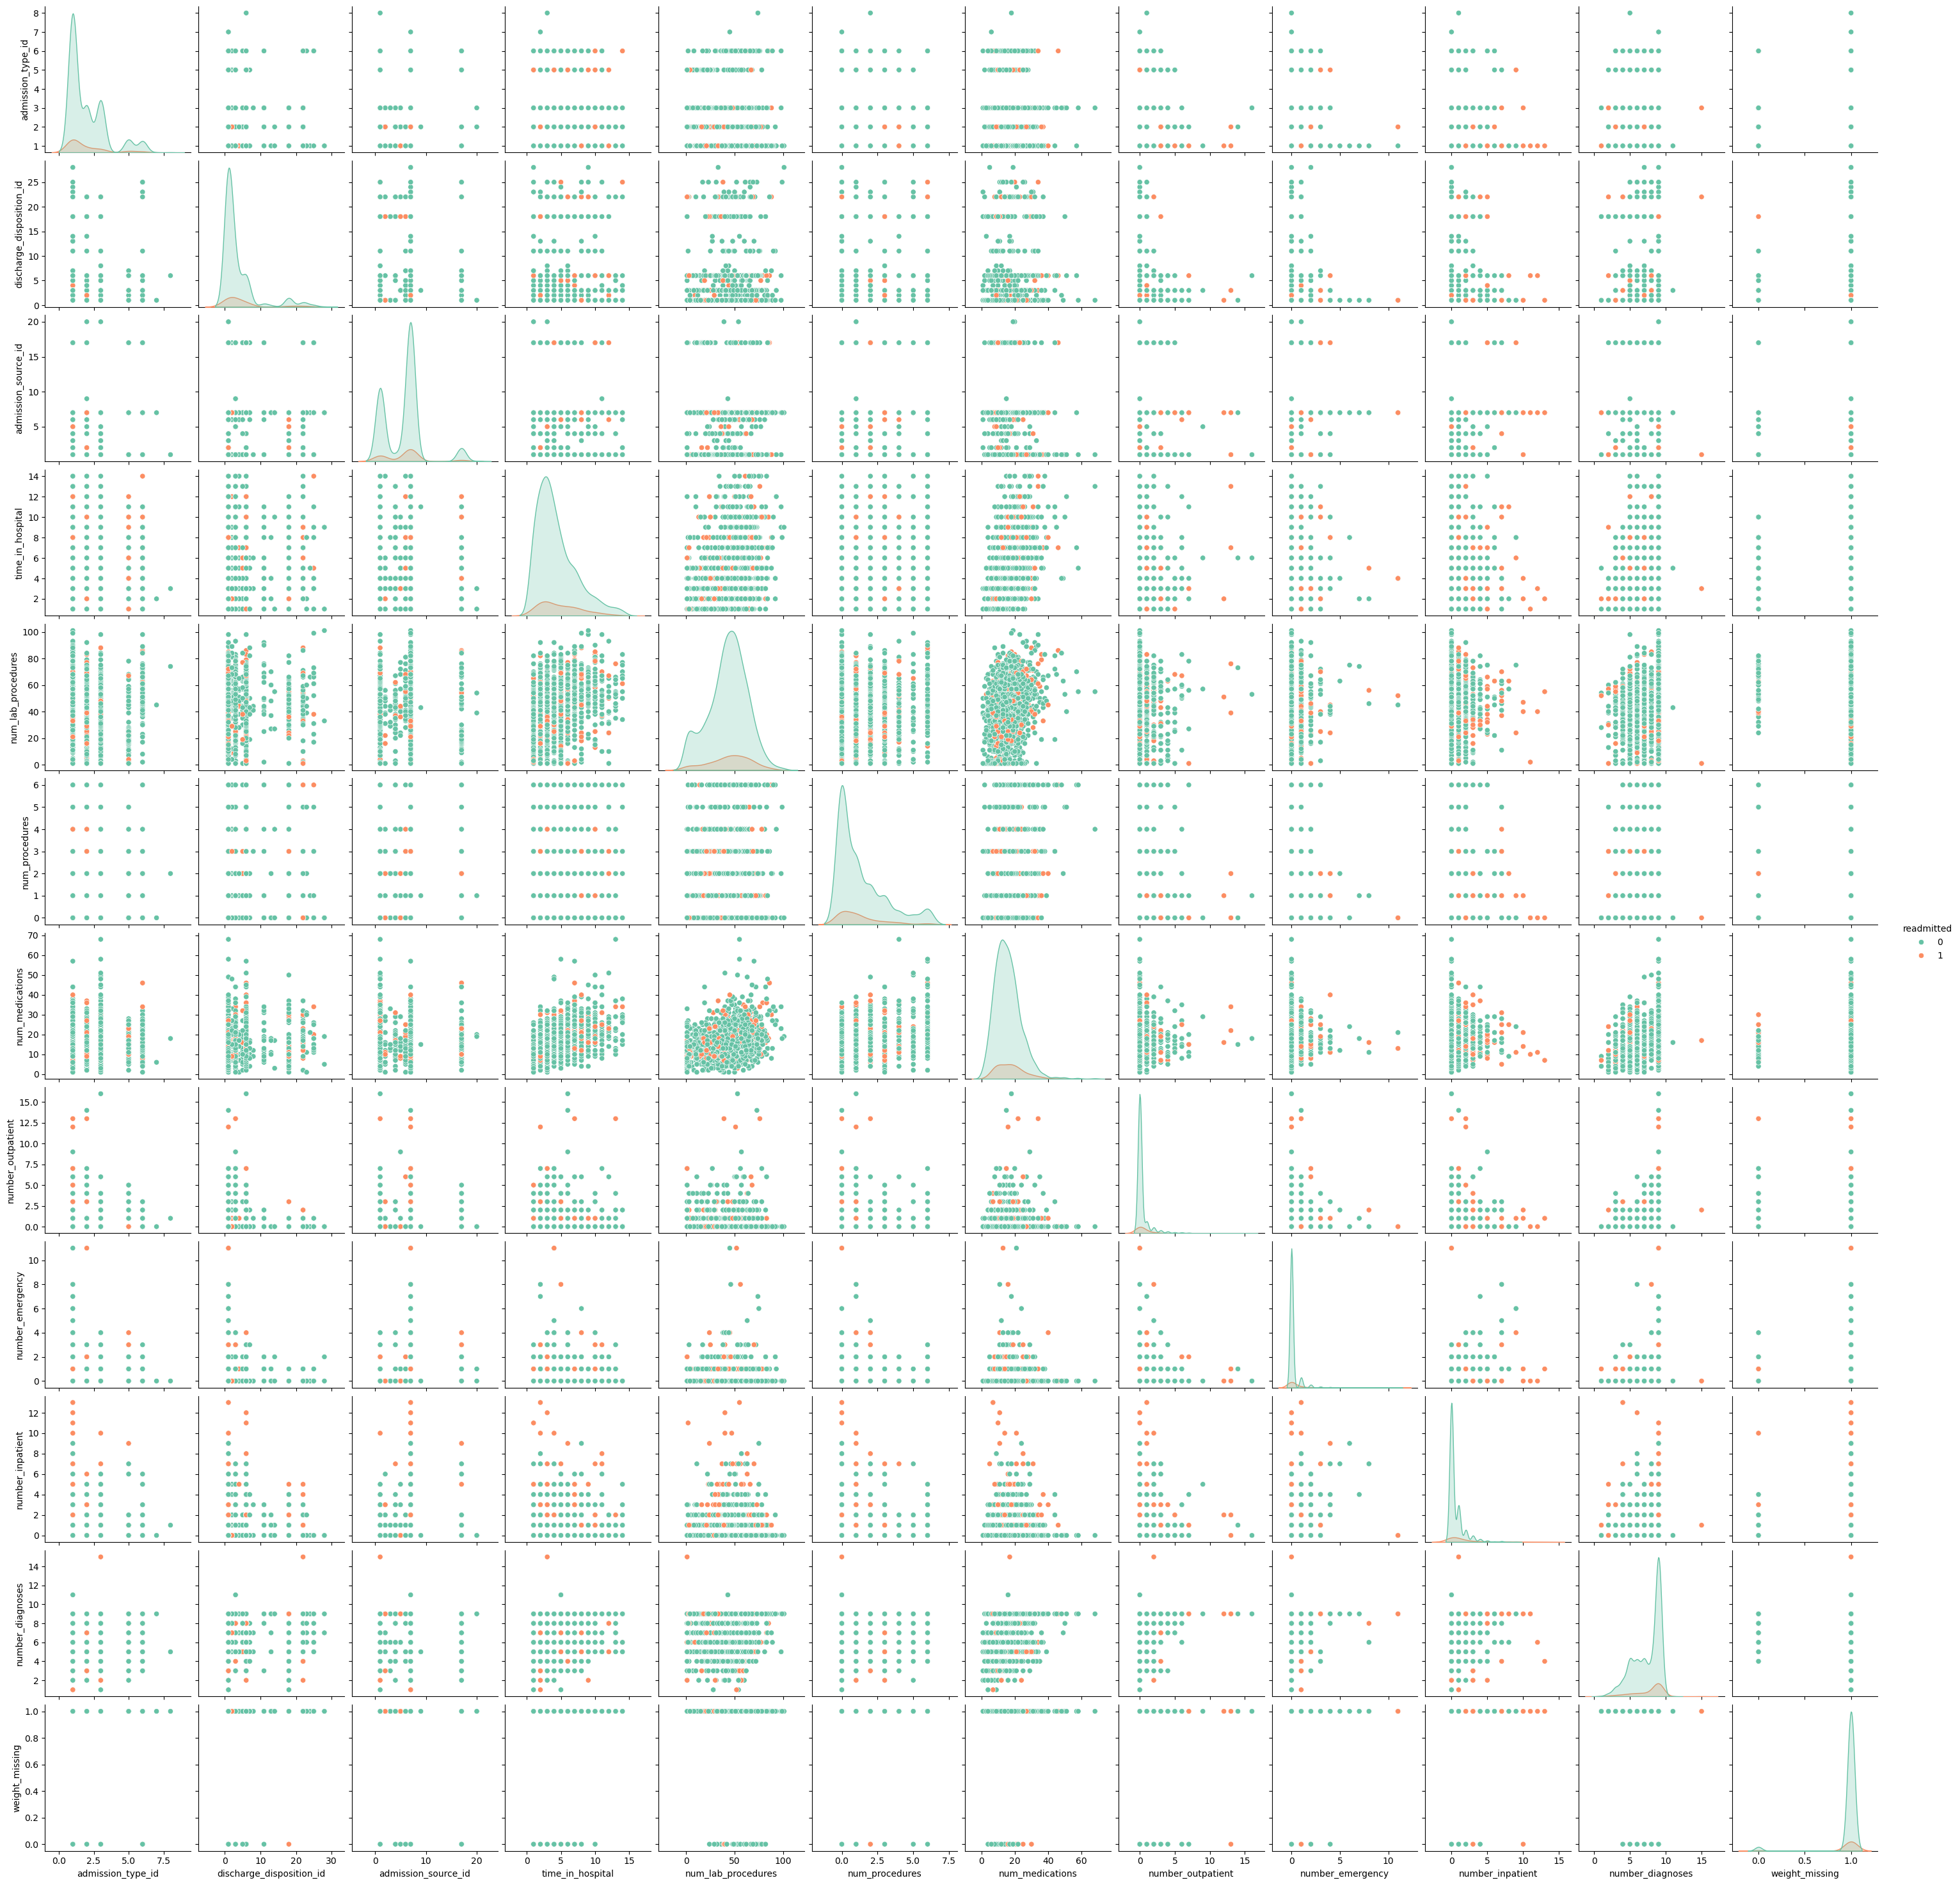

In [25]:
# Pairplot para analisar as relações entre as variáveis numéricas
df_plot = X.copy()
df_plot['readmitted'] = y.astype(str)
sns.pairplot(df_plot.sample(1500),
             vars=numeric_cols,
             diag_kind='kde',
             hue='readmitted',
             palette='Set2')

In [ ]:
# Testando com KNN

knn_model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=3, random_state=42, max_iter=1000))
])

knn_model.fit(x_train, y_train)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat_unknown', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [27]:
y_hat_train = knn_model.predict(x_train)
y_hat_test = knn_model.predict(x_test)

In [28]:
print("Acurácia no conjunto de treino: ", accuracy_score(y_train, y_hat_train))
print("Acurácia no conjunto de teste: ", accuracy_score(y_test, y_hat_test))

Acurácia no conjunto de treino:  0.905086622663228
Acurácia no conjunto de teste:  0.8645266950540452


In [29]:
print("-"*100)
print("Matriz de confusão (KNN):")
print(confusion_matrix(y_test, y_hat_test))
print("-"*100)
print("Classification Report (KNN):")
print(classification_report(y_test, y_hat_test))

----------------------------------------------------------------------------------------------------
Matriz de confusão (KNN):
[[26104  1019]
 [ 3117   290]]
----------------------------------------------------------------------------------------------------
Classification Report (KNN):
              precision    recall  f1-score   support

           0       0.89      0.96      0.93     27123
           1       0.22      0.09      0.12      3407

    accuracy                           0.86     30530
   macro avg       0.56      0.52      0.52     30530
weighted avg       0.82      0.86      0.84     30530



# _Comparaçao dos Modelos:_

* KNN
    * Tem acurácia alta
    * Praticamente ignora a classe minoritária
    * Recall muito baixo (Detecta apenas 9% dos pacientes de risco)
    * Muitas features categóricas explodem dimensionalidade
    * Falso Negativo muito alto, acerta apenas 290
---
    Está favorecendo a classe majoritária
---
* Perceptron (balanceada)
    * Acurária baixa
    * Recall muito alto baixo
    * Muitos falsos-positivos
---
    Recall altíssimo, mas gera falsos-positivos demais.
---
* Regressao Logística (balanceada)
    * Acurácia aceitável
    * Recall razoável
    * Melhor F1-score da classe 1

    ### Melhor até agora
---
* Accuracy pode ser enganosa em datasets desbalanceados 
* Modelos não balanceados favorecem a classe majoritária 
* Ajuste de class_weight muda completamente o comportamento do modelo
---

In [30]:
# Pegando as probabilidades preditas para a classe 1 (readmitidos em menos de 30 dias)
y_prob = model.predict_proba(x_test)[:, 1]

In [31]:
# Testando diferentes thresholds para a classificação
# O threshold padrão é 0.5, ou seja, se a probabilidade predita for maior ou igual a 0.5, 
# o modelo classifica como 1 (readmitido), caso contrário, classifica como 0 (não readmitido).
# O melhor threshold depende do trade-off entre precisão e recall que queremos alcançar, 
# e pode ser ajustado de acordo com as necessidades do problema em questão.
# O threshold de 0.60 é o que apresenta melhor equilíbrio entre precisão e recall para a classe 1

# Em contexto hospitalar normalmente o recall é mais importante que a precisão, pois perder 
# um paciente de risco pode gerar custo e complicação clínica.
# Apesar do threshold de 0.50 apresentar F1 score ligeiramente mais alto, a precisao cai para 0.163
# O threshold de 0.60 é o que apresenta melhor equilíbrio entre precisão e recall e F1 score para a classe 1

# O threshold de 0.45 apresenta um recall de 0.648, mas a precisão cai para 0.152. Buscando um balanceado com F1 score

thresholds = np.arange(0.05, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_adj = (y_prob >= t).astype(int)
    
    recall = recall_score(y_test, y_pred_adj)
    precision = precision_score(y_test, y_pred_adj)
    f1 = f1_score(y_test, y_pred_adj)
    
    results.append((t, recall, precision, f1))

for r in results:
    print(f"Threshold: {r[0]:.2f} | Recall: {r[1]:.3f} | Precision: {r[2]:.3f} | F1: {r[3]:.3f}")

Threshold: 0.05 | Recall: 0.998 | Precision: 0.112 | F1: 0.202
Threshold: 0.10 | Recall: 0.993 | Precision: 0.113 | F1: 0.203
Threshold: 0.15 | Recall: 0.983 | Precision: 0.114 | F1: 0.204
Threshold: 0.20 | Recall: 0.969 | Precision: 0.116 | F1: 0.207
Threshold: 0.25 | Recall: 0.947 | Precision: 0.119 | F1: 0.211
Threshold: 0.30 | Recall: 0.903 | Precision: 0.124 | F1: 0.217
Threshold: 0.35 | Recall: 0.829 | Precision: 0.130 | F1: 0.225
Threshold: 0.40 | Recall: 0.732 | Precision: 0.140 | F1: 0.235
Threshold: 0.45 | Recall: 0.621 | Precision: 0.154 | F1: 0.247
Threshold: 0.50 | Recall: 0.498 | Precision: 0.167 | F1: 0.250
Threshold: 0.55 | Recall: 0.390 | Precision: 0.187 | F1: 0.252
Threshold: 0.60 | Recall: 0.286 | Precision: 0.204 | F1: 0.238
Threshold: 0.65 | Recall: 0.211 | Precision: 0.231 | F1: 0.221
Threshold: 0.70 | Recall: 0.142 | Precision: 0.257 | F1: 0.183
Threshold: 0.75 | Recall: 0.096 | Precision: 0.299 | F1: 0.145
Threshold: 0.80 | Recall: 0.062 | Precision: 0.347 | F1

In [32]:
# Filtrando os resultados para identificar os thresholds que apresentam recall maior ou igual a 0.60
filtered = [r for r in results if r[1] >= 0.60 and r[3] >= 0.24]
filtered

[(np.float64(0.45),
  0.621074258878779,
  0.15393569038265678,
  0.24672069025826385)]

In [44]:
best_threshold = 0.50

y_final = (y_prob >= best_threshold).astype(int)

print(classification_report(y_test, y_final))

              precision    recall  f1-score   support

           0       0.92      0.69      0.79     27123
           1       0.17      0.50      0.25      3407

    accuracy                           0.67     30530
   macro avg       0.54      0.59      0.52     30530
weighted avg       0.83      0.67      0.73     30530



Recall = 0.62 (bem alto)

* F1 = 0.25 (muito próximo dos melhores scores)

* Captura mais pacientes de risco

* A precisão é baixa (0.15), mas isso é esperado com base desbalanceada.

No geral, o threshold de 50% tem os melhores classificadores gerais.

In [34]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = 2 * (precision * recall) / (precision + recall)
best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]
print("Best threshold:", best_threshold)

display(thresholds)

Best threshold: 0.997307500250778


/tmp/ipykernel_9805/2967706627.py:3: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)


array([0.00307499, 0.00397115, 0.00457611, ..., 0.99235214, 0.99513572,
       0.9973075 ], shape=(30530,))

In [35]:
# Aplicando o melhor threshold encontrado
y_final = (y_prob >= 0.45).astype(int)

print(classification_report(y_test, y_final))

              precision    recall  f1-score   support

           0       0.92      0.57      0.71     27123
           1       0.15      0.62      0.25      3407

    accuracy                           0.58     30530
   macro avg       0.54      0.60      0.48     30530
weighted avg       0.84      0.58      0.65     30530



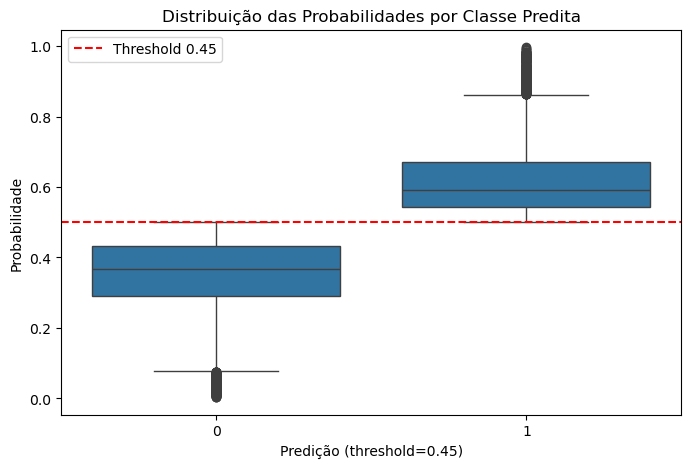

In [46]:
threshold = 0.50

# Probabilidades da classe 1
y_prob = model.predict_proba(x_test)[:, 1]

# Classificação com novo threshold
y_pred_new = (y_prob >= threshold).astype(int)

# Criar DataFrame
df_plot = pd.DataFrame({
    "Probabilidade": y_prob,
    "Predição (threshold=0.45)": y_pred_new
})

# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x="Predição (threshold=0.45)", y="Probabilidade", data=df_plot)
plt.axhline(threshold, color='red', linestyle='--', label='Threshold 0.45')
plt.legend()
plt.title("Distribuição das Probabilidades por Classe Predita")
plt.show()

* Classe 0 predita → probabilidades concentradas abaixo de 0.5

* Classe 1 predita → probabilidades acima de 0.5

* A linha vermelha está exatamente no ponto de decisão

Isso confirma que o threshold está sendo aplicado corretamente.

* A mediana da classe 1 está por volta de 0.55–0.60

* A mediana da classe 0 está ~0.35

* Há separação, mas não é enorme, por isso o recall e precision não são muito altos.

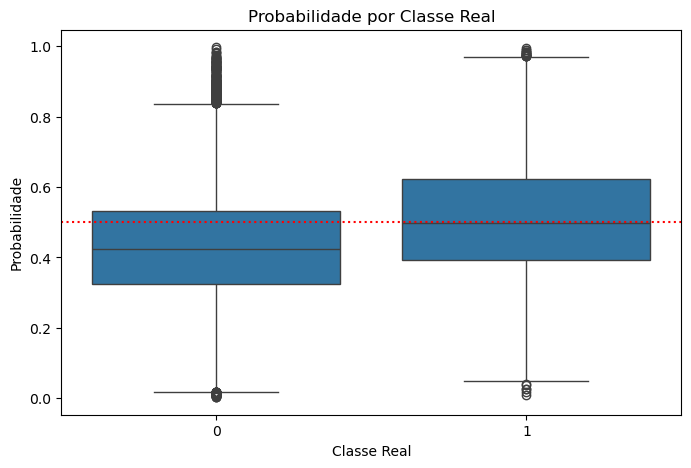

In [47]:
df_plot = pd.DataFrame({
    "Probabilidade": y_prob,
    "Classe Real": y_test
})

plt.figure(figsize=(8,5))
sns.boxplot(x="Classe Real", y="Probabilidade", data=df_plot)
plt.axhline(threshold, color='red', linestyle=':')
plt.title("Probabilidade por Classe Real")
plt.show()

In [48]:
# As distribuições das probabilidades das duas classes estão muito sobrepostas.
# O modelo não separa bem as classes.
# A mediana da classe 1 está praticamente em 0.5.
# Isso indica que o modelo está em dúvida sobre a maioria dos casos positivos.

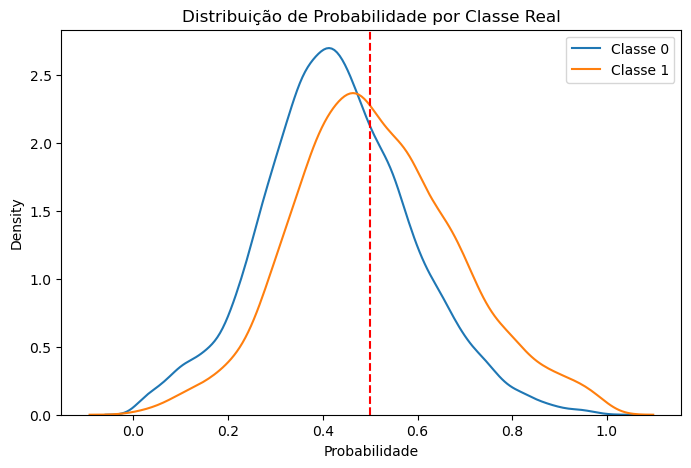

In [49]:
plt.figure(figsize=(8,5))

sns.kdeplot(df_plot[df_plot["Classe Real"]==0]["Probabilidade"], label="Classe 0")
sns.kdeplot(df_plot[df_plot["Classe Real"]==1]["Probabilidade"], label="Classe 1")

plt.axvline(threshold, color='red', linestyle='--')
plt.title("Distribuição de Probabilidade por Classe Real")
plt.legend()
plt.show()

In [39]:
# minuto 56 video 3. separar treino e teste antes de fazer qualquer análise exploratória.